# Notebook 02: Structuring the Annotated Dataset, Splits and Preprocessing Pipeline

Notebook 01 produced a full inventory of the 27,560 cell images with a quality audit (corruption, duplicates, dimensions). This notebook turns that inventory into a **structured, annotated dataset ready for model training**: a reproducible stratified train/validation/test split, and a preprocessing pipeline (resize, normalization, augmentation) implemented as PyTorch `Dataset`/`DataLoader` classes.

## 1. Load the clean manifest

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

sns.set_theme(style="whitegrid")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

inventory = pd.read_csv(PROCESSED_DIR / "inventory.csv")
print(f"Full manifest: {len(inventory):,} rows")
inventory.head(3)

Full manifest: 27,558 rows


,path,label,filename,file_size_bytes,width,height,mode,md5,corrupted,duplicate
0,data\raw\cell_images\Parasitized\C100P61ThinF_...,Parasitized,C100P61ThinF_IMG_20150918_144104_cell_162.png,14025,142,148,RGB,6b60535df837d603b2f591d154940f1a,False,False
1,data\raw\cell_images\Parasitized\C100P61ThinF_...,Parasitized,C100P61ThinF_IMG_20150918_144104_cell_163.png,18152,148,208,RGB,142cdfcc8f5d2afcdd327e4886a4fbf8,False,False
2,data\raw\cell_images\Parasitized\C100P61ThinF_...,Parasitized,C100P61ThinF_IMG_20150918_144104_cell_164.png,12825,139,151,RGB,2db29c733097f1736cdba4055e1549d6,False,False


In [2]:
clean = inventory.loc[(~inventory["corrupted"]) & (~inventory["duplicate"])].reset_index(drop=True)

display(
    Markdown(
        f"**Excluded:** `{inventory['corrupted'].sum()}` corrupted + `{inventory['duplicate'].sum()}` duplicate rows.  \n"
        f"**Usable images:** `{len(clean):,}`"
    )
)
clean["label"].value_counts()

**Excluded:** `0` corrupted + `0` duplicate rows.  
**Usable images:** `27,558`

label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64

## 2. Stratified train / validation / test split

A 70/15/15 split is built with a fixed random seed (42) and stratified on `label` so each split keeps the same class balance as the full dataset. The split is done in two steps with `sklearn.model_selection.train_test_split`: first carve out 70% for training, then split the remaining 30% evenly into validation and test.

**Caveat:** the split is at the image level, not the patient/slide level. Filenames encode a slide identifier (e.g. `C116P77...`), and several cells are cropped from the same microscopy field, so a stricter protocol would group by slide to fully prevent any leakage between splits. This is flagged here as a known simplification and revisited as a limitation in Notebook 04. For this portfolio-scale benchmark the priority is a clean, reproducible label-stratified split.

In [3]:
train_df, temp_df = train_test_split(
    clean, test_size=0.30, stratify=clean["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(df):6,} images ({len(df) / len(clean):.1%})")

split_summary = pd.concat(
    {
        "train": train_df["label"].value_counts(),
        "val": val_df["label"].value_counts(),
        "test": test_df["label"].value_counts(),
    },
    axis=1,
)
split_summary["train_%"] = (split_summary["train"] / split_summary["train"].sum() * 100).round(2)
split_summary["val_%"] = (split_summary["val"] / split_summary["val"].sum() * 100).round(2)
split_summary["test_%"] = (split_summary["test"] / split_summary["test"].sum() * 100).round(2)
display(split_summary)

train: 19,290 images (70.0%)
val  :  4,134 images (15.0%)
test :  4,134 images (15.0%)


,train,val,test,train_%,val_%,test_%
label,,,,,,
Uninfected,9645,2067,2067,50.0,50.0,50.0
Parasitized,9645,2067,2067,50.0,50.0,50.0


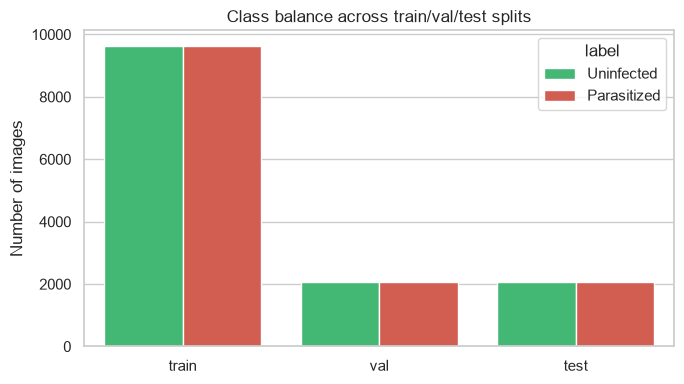

In [4]:
plt.figure(figsize=(7, 4))
plot_df = split_summary[["train", "val", "test"]].reset_index().melt(
    id_vars="label", var_name="split", value_name="count"
)
sns.barplot(data=plot_df, x="split", y="count", hue="label", palette={"Parasitized": "#e74c3c", "Uninfected": "#2ecc71"})
plt.title("Class balance across train/val/test splits")
plt.ylabel("Number of images")
plt.xlabel("")
plt.tight_layout()
plt.show()

The split preserves the ~50/50 class balance in all three subsets, as expected from stratification. Class balance being (near-)identical across splits means accuracy will not be misleading on its own in Notebook 03/04, though the clinically-relevant metrics (sensitivity, specificity, PPV, NPV) are still tracked separately in Notebook 04 since real-world prevalence is far from 50/50.

## 3. Preprocessing pipeline

**Resize target: 64×64 px.** Source images are small, low-resolution single-cell crops (median size around 130×130 px per Notebook 01) with no fine sub-cellular detail beyond the stain pattern, and training runs on CPU only (no CUDA on this machine). 64×64 keeps each forward/backward pass fast enough to train multiple models within a few minutes while retaining enough resolution to see the parasite stain clearly, verified visually below.

**Normalization:** ImageNet mean/std (`[0.485, 0.456, 0.406]` / `[0.229, 0.224, 0.225]`) is used for both the from-scratch CNN and the transfer-learning model in Notebook 03, rather than dataset-specific statistics. This keeps the two pipelines directly comparable and is required for the transfer-learning branch anyway, since `resnet18`'s pretrained filters expect ImageNet-normalized input.

**Augmentation (train split only):** random horizontal flip, random vertical flip, and a small random rotation (±15°). Cell orientation under the microscope is arbitrary, so these flips/rotations are label-preserving and only make the training set more representative of unseen slide orientations. No augmentation is applied to validation/test, since those must reflect the data as it actually arrives.

In [5]:
IMG_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(train_transform)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 4. PyTorch `Dataset` and `DataLoader`

In [6]:
LABEL_TO_IDX = {"Uninfected": 0, "Parasitized": 1}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}


class MalariaCellDataset(Dataset):
    '''Single-cell blood smear images, loaded from the manifest CSVs.'''

    def __init__(self, manifest_df: pd.DataFrame, root_dir: Path, transform=None):
        self.df = manifest_df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root_dir / row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = LABEL_TO_IDX[row["label"]]
        return img, label


train_dataset = MalariaCellDataset(train_df.assign(label=train_df["label"]), PROJECT_ROOT, transform=train_transform)
val_dataset = MalariaCellDataset(val_df, PROJECT_ROOT, transform=eval_transform)
test_dataset = MalariaCellDataset(test_df, PROJECT_ROOT, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

batch_x, batch_y = next(iter(train_loader))
print(f"train_dataset: {len(train_dataset):,} | val_dataset: {len(val_dataset):,} | test_dataset: {len(test_dataset):,}")
print(f"Batch shape: {batch_x.shape}, dtype {batch_x.dtype}; labels shape {batch_y.shape}")

train_dataset: 19,290 | val_dataset: 4,134 | test_dataset: 4,134
Batch shape: torch.Size([32, 3, 64, 64]), dtype torch.float32; labels shape torch.Size([32])


### Sanity check: visualize a batch of augmented training images

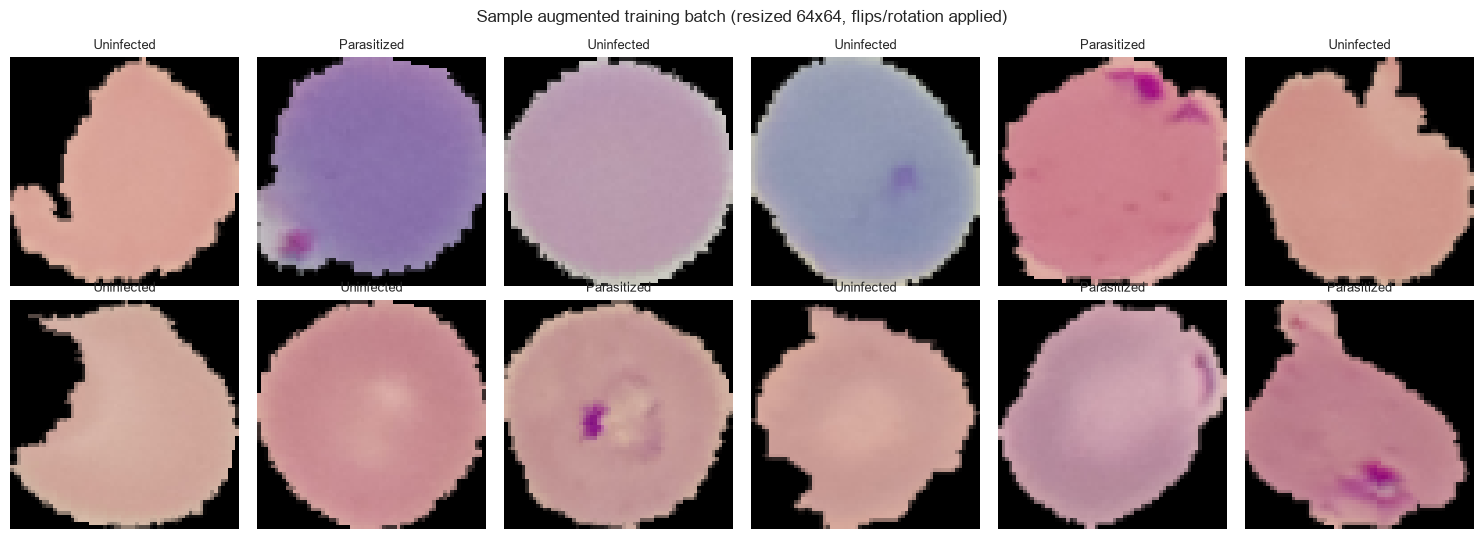

In [7]:
def denormalize(tensor_img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor_img * std + mean).clamp(0, 1)


fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for i in range(12):
    img = denormalize(batch_x[i]).permute(1, 2, 0).numpy()
    ax = axes[i // 6, i % 6]
    ax.imshow(img)
    ax.set_title(IDX_TO_LABEL[batch_y[i].item()], fontsize=9)
    ax.axis("off")
fig.suptitle("Sample augmented training batch (resized 64x64, flips/rotation applied)", fontsize=12)
plt.tight_layout()
plt.show()

Even at 64×64 resolution the stain pattern that distinguishes parasitized from uninfected cells remains visible, which supports the resolution/speed tradeoff made above. Augmented crops (flipped/rotated) still look like plausible microscopy fields, confirming the transforms are label-preserving.

## 5. Export annotated manifests

In [8]:
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    out_path = PROCESSED_DIR / f"{name}.csv"
    df[["path", "label"]].to_csv(out_path, index=False)
    print(f"Saved {out_path.name}: {len(df):,} rows")

Saved train.csv: 19,290 rows
Saved val.csv: 4,134 rows
Saved test.csv: 4,134 rows


## Summary and handoff to Notebook 03

* Stratified 70/15/15 split, seed 42, saved as `data/processed/{train,val,test}.csv`; sizes reported in Section 2 above.
* Preprocessing: resize to 64x64, ImageNet normalization, train-only augmentation (horizontal/vertical flip, plus or minus 15 degrees rotation).
* `MalariaCellDataset` / `DataLoader` classes defined and sanity-checked on a real batch.
* Known simplification: split is image-level, not slide-level, acknowledged as a limitation, not hidden.